## Flujo del notebook

```
Setup --> Descubrimiento --> Metadata --> Validaciones RAVDESS --> Targets --> Particiones --> Folds CV --> Trimming --> Auditorías --> Reporte
```

## 0 · Setup de entorno

Agrega la raíz del proyecto al `sys.path` para poder importar `src/` desde cualquier ubicación.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\alega\OneDrive\Documentos\std\Speech_Emotion_Recognition


---
## 1 · Configuración y seed

Toda configuración se lee de `configs/config.yaml` — ningún valor está hardcodeado en el notebook.

In [2]:
from src.utils.config import get_config, resolve_path
from src.utils.reproducibility import set_global_seed
from src.utils.logging import get_logger

cfg = get_config()
logger = get_logger("sprint1")
set_global_seed(cfg.seed)

# Paths (desde config, nunca hardcodeados)
RAW_DIR = resolve_path(cfg.paths.data_raw)
AUDIO_TRIMMED_DIR = resolve_path(cfg.paths.audio_trimmed)
METADATA_PATH = resolve_path(cfg.paths.metadata)
SPLITS_PATH = resolve_path(cfg.paths.splits)
FIGURES_DIR = resolve_path(cfg.paths.figures_dir)
REPORTS_DIR = resolve_path(cfg.paths.reports_dir)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Parámetros de splits
SEED = cfg.seed
TEST_INDEPENDENT_ACTORS = list(cfg.splits.test_independent_actors)
CV_FOLDS = cfg.splits.cv_folds

# Parámetros de audio
SAMPLE_RATE = cfg.audio.sample_rate
FRAME_LENGTH_MS = cfg.audio.frame_length_ms
HOP_LENGTH_MS = cfg.audio.hop_length_ms
THRESHOLD_DB = cfg.audio.threshold_db
PADDING_MS = cfg.audio.padding_ms
TRIM_RATIO_WARN = cfg.audio.trim_ratio_warning


print("        CONFIGURACIÓN DE ENTORNO     ")
print("══════════════════════════════════════════")
print(f"Seed global: {SEED:<20} ")
print(f"CV Folds: {CV_FOLDS:<20}")
print(f"Actores test indep.: {str(TEST_INDEPENDENT_ACTORS):<20}")
print(f"Sample rate: {SAMPLE_RATE} Hz{'':<11} ")
print(f"Trim threshold: {THRESHOLD_DB} dB{'':<13} ")
print(f"Padding: {PADDING_MS} ms{'':<13} ")
print("══════════════════════════════════════════")

        CONFIGURACIÓN DE ENTORNO     
══════════════════════════════════════════
Seed global: 42                   
CV Folds: 5                   
Actores test indep.: [2, 6, 21, 23]      
Sample rate: 48000 Hz            
Trim threshold: -35 dB              
Padding: 150 ms              
══════════════════════════════════════════


---
## 2 · Descubrimiento de audios

RAVDESS speech (modalidad `audio_only`, prefijo `03`) contiene exactamente **1440 archivos**:

```
24 actores × [
    7 emociones con intensidad × 2 intensidades × 2 statements × 2 reps --> 1344
    1 neutral (solo intensidad normal) × 2 statements × 2 reps --> 96
    ] = 1440
```

In [3]:
from src.data.metadata import discover_audio_files

audio_files = discover_audio_files(RAW_DIR, modality="audio_only")

print(f"Archivos .wav descubiertos (audio_only): {len(audio_files)}")
print(f"\nMuestra de nombres (primero / último):")
print(f"Primero: {audio_files[0].name}")
print(f"Último: {audio_files[-1].name}")

assert len(audio_files) == 1440, f"Esperados 1440 archivos, encontrados: {len(audio_files)}"
print(f"\nConteo: {len(audio_files)} archivos encontrados.")

2026-07-04 15:02:35 | INFO     | src.data.metadata | Archivos .wav descubiertos (audio_only): 1440
Archivos .wav descubiertos (audio_only): 1440

Muestra de nombres (primero / último):
Primero: 03-01-01-01-01-01-01.wav
Último: 03-01-08-02-02-02-24.wav

Conteo: 1440 archivos encontrados.


---
## 3 · Construcción de metadata

Se parsea el naming convention RAVDESS (`03-01-{emo}-{int}-{stmt}-{rep}-{actor}.wav`) y se construyen:
- **Columnas de identidad:** `actor_id`, `sex`, `modality`, `vocal_channel`
- **Columnas de estímulo:** `emotion_original`, `intensity`, `statement`, `repetition_id`
- **Columnas de target:** `emotion_quadrant` (Russell 1980)
- **Columna de agrupación:** `utterance_group_id` (para mantener repeticiones juntas en CV)
- **Columnas de trimming:** se inicializan como `NaN` y se completan en la sección 8

In [4]:
from src.data.metadata import build_metadata

metadata = build_metadata(
    raw_dir=RAW_DIR,
    audio_trimmed_dir=AUDIO_TRIMMED_DIR,
)

print(f"Metadata construida: {len(metadata)} registros, "
      f"{metadata['actor_id'].nunique()} actores, "
      f"{metadata['emotion_original'].nunique()} emociones.")
print(f"Shape: {metadata.shape}")
print("\nColumnas disponibles:")
cols = metadata.columns.tolist()
for i in range(0, len(cols), 5):
    print("  " + ", ".join(cols[i:i+5]))

2026-07-04 15:02:35 | INFO     | src.data.metadata | Archivos .wav descubiertos (audio_only): 1440
2026-07-04 15:02:37 | INFO     | src.data.metadata | Metadata construida: 1440 registros, 24 actores, 8 emociones.
Metadata construida: 1440 registros, 24 actores, 8 emociones.
Shape: (1440, 23)

Columnas disponibles:
  file_id, file_path_raw, modality_code, modality, vocal_channel_code
  vocal_channel, emotion_code, emotion_original, intensity_code, intensity
  statement_code, statement, repetition_id, actor_id, sex
  emotion_quadrant, utterance_group_id, file_path_trimmed, duration_raw_s, duration_trimmed_s
  trim_ratio, trim_start_s, trim_end_s


In [5]:
# Vista previa: columnas clave para verificar parseo
preview_cols = [
    "file_id", "actor_id", "sex",
    "emotion_original", "intensity", "statement",
    "repetition_id", "emotion_quadrant", "utterance_group_id",
]
metadata[preview_cols].head(6)

,file_id,actor_id,sex,emotion_original,intensity,statement,repetition_id,emotion_quadrant,utterance_group_id
0,03-01-01-01-01-01-01,1,male,neutral,normal,kids,1,Q4,a01_neutral_normal_kids
1,03-01-01-01-01-01-02,2,female,neutral,normal,kids,1,Q4,a02_neutral_normal_kids
2,03-01-01-01-01-01-03,3,male,neutral,normal,kids,1,Q4,a03_neutral_normal_kids
3,03-01-01-01-01-01-04,4,female,neutral,normal,kids,1,Q4,a04_neutral_normal_kids
4,03-01-01-01-01-01-05,5,male,neutral,normal,kids,1,Q4,a05_neutral_normal_kids
5,03-01-01-01-01-01-06,6,female,neutral,normal,kids,1,Q4,a06_neutral_normal_kids


---
## 4 · Validaciones RAVDESS

Verificamos que el parseo respeta la especificación oficial del dataset:
- `neutral` solo existe en intensidad `normal`
- Cada `utterance_group_id` tiene exactamente 2 repeticiones
- El sexo del actor es consistente con el `actor_id` (impares = masculino, pares = femenino)

In [6]:
from src.data.metadata import validate_metadata_basic

validate_metadata_basic(metadata)

print("\nVerificaciones específicas RAVDESS:")

# neutral solo tiene intensidad normal
neutral_int = metadata.loc[metadata["emotion_original"] == "neutral", "intensity"].unique()
ok = "OK" if list(neutral_int) == ["normal"] else "ERR"
print(f"Intensidades de neutral: {list(neutral_int)}  {ok}")

# Dos repeticiones exactas por grupo
rep_counts = metadata.groupby("utterance_group_id")["repetition_id"].count()
unique_rep_counts = rep_counts.unique()
ok = "OK" if len(unique_rep_counts) == 1 and unique_rep_counts[0] == 2 else "ERR"
print(f"Repeticiones por grupo (único valor): {unique_rep_counts[0]}  {ok}")

# Consistencia sexo-actor
from src.config.contracts import actor_sex
sex_errors = metadata[metadata.apply(
    lambda r: actor_sex(r["actor_id"]) != r["sex"], axis=1
)]
ok = "OK" if len(sex_errors) == 0 else "ERR"
print(f"Actores con sexo inconsistente: {len(sex_errors)}  {ok}")

2026-07-04 15:02:37 | INFO     | src.data.metadata | ✓ Validaciones básicas de metadata: OK

Verificaciones específicas RAVDESS:
Intensidades de neutral: ['normal']  OK
Repeticiones por grupo (único valor): 2  OK
Actores con sexo inconsistente: 0  OK


---
## 5 · Distribución de targets

El proyecto define **dos targets**:

| Target | Clases | Descripción |
|---|---|---|
| `emotion_original` | 8 | Etiquetas nativas RAVDESS |
| `emotion_quadrant` | 4 | Cuadrantes del circumplex de Russell (1980) |

**Mapping emoción → cuadrante:**

| Cuadrante | Emociones | Descripción |
|---|---|---|
| Q1 | happy, surprised | High Valence / High Arousal |
| Q2 | angry, fearful, disgust | Low Valence / High Arousal |
| Q3 | sad | Low Valence / Low Arousal |
| Q4 | calm, neutral | High Valence / Low Arousal |

> **Desbalance esperado:** Q2 agrupa 3 emociones (576 muestras) mientras Q3 solo contiene sad (192 muestras) — una razón 3:1 que se aborda en Sprint 3 con `class_weight='balanced'`. Además, dentro de las 8 clases originales `neutral` tiene la mitad de muestras que el resto (96 vs. 192): RAVDESS no graba una versión "strong" de neutral, así que la asimetría es propia del diseño del corpus y no un artefacto de nuestro pipeline.

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from src.config.contracts import QUADRANT_LABELS

# Resumen en consola (barras ASCII)
emo_counts = metadata["emotion_original"].value_counts().sort_index()
q_counts = metadata["emotion_quadrant"].value_counts().sort_index()
max_count = emo_counts.max()

print("Emotion_original (8 clases)")
for emo, cnt in emo_counts.items():
    bar = "█" * int(cnt / max_count * 20)
    print(f"{emo:<12} {cnt:>4}  {bar}")

q_labels_short = {
    "Q1": "Q1 (happy + surprised)",
    "Q2": "Q2 (angry + fearful + disgust)",
    "Q3": "Q3 (sad)",
    "Q4": "Q4 (calm + neutral)",
}
print("\nEmotion_quadrant (4 cuadrantes)")
for q, cnt in q_counts.items():
    bar = "█" * int(cnt / q_counts.max() * 30)
    print(f"{q_labels_short[q]:<35} {cnt:>4}  {bar}")

Emotion_original (8 clases)
angry         192  ████████████████████
calm          192  ████████████████████
disgust       192  ████████████████████
fearful       192  ████████████████████
happy         192  ████████████████████
neutral        96  ██████████
sad           192  ████████████████████
surprised     192  ████████████████████

Emotion_quadrant (4 cuadrantes)
Q1 (happy + surprised)               384  ████████████████████
Q2 (angry + fearful + disgust)       576  ██████████████████████████████
Q3 (sad)                             192  ██████████
Q4 (calm + neutral)                  288  ███████████████


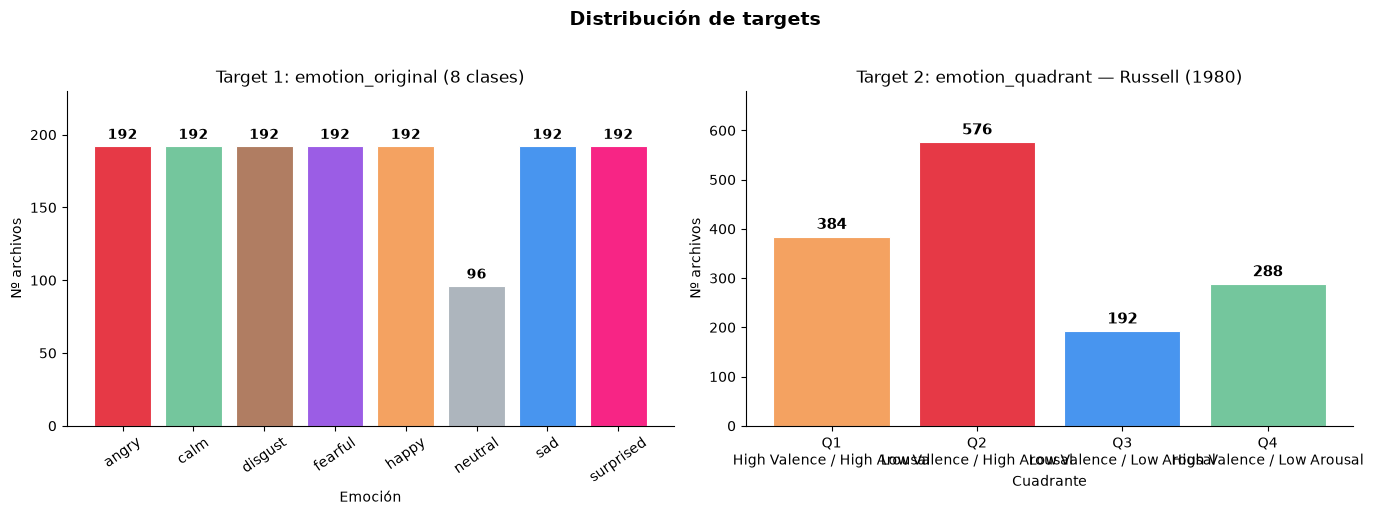

Figura guardada: reports/figures/targets_distribution.png


In [8]:
# Figura
EMOTION_COLORS = {
    "neutral":"#ADB5BD",
    "calm":"#74C69D",
    "happy":"#F4A261",
    "sad":"#4895EF",
    "angry":"#E63946",
    "fearful":"#9B5DE5",
    "disgust":"#B07D62",
    "surprised":"#F72585",
}
Q_COLORS = ["#F4A261","#E63946","#4895EF","#74C69D"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribución de targets", fontsize=14, fontweight="bold", y=1.02)

# Subplot 1: emotion_original
bar1 = axes[0].bar(
    emo_counts.index,
    emo_counts.values,
    color=[EMOTION_COLORS[e] for e in emo_counts.index],
    edgecolor="white", linewidth=0.8,
)
axes[0].bar_label(bar1, padding=3, fontsize=10, fontweight="bold")
axes[0].set_title("Target 1: emotion_original (8 clases)", fontsize=12)
axes[0].set_xlabel("Emoción")
axes[0].set_ylabel("Nº archivos")
axes[0].tick_params(axis="x", rotation=35)
axes[0].set_ylim(0, 230)
axes[0].spines[["top", "right"]].set_visible(False)

# Subplot 2: emotion_quadrant
q_label_list = [f"{q}\n{QUADRANT_LABELS[q]}" for q in q_counts.index]
bar2 = axes[1].bar(q_label_list, q_counts.values, color=Q_COLORS, edgecolor="white", linewidth=0.8)
axes[1].bar_label(bar2, padding=3, fontsize=11, fontweight="bold")
axes[1].set_title("Target 2: emotion_quadrant — Russell (1980)", fontsize=12)
axes[1].set_xlabel("Cuadrante")
axes[1].set_ylabel("Nº archivos")
axes[1].set_ylim(0, 680)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "targets_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: reports/figures/targets_distribution.png")

---
## 6 · Diseño de particiones

Se definen dos particiones **globales y disjuntas**. Una vez fijadas, son **inmutables** para todo el proyecto.

### Estrategia

| Partición | Criterio | Uso |
|---|---|---|
| `test_speaker_independent` | 4 actores completos (2M + 2F) | Evalúa generalización a hablantes **nunca vistos** |
| `development` | Todo lo restante | EDA, CV, selección de features, tuning |

El proyecto se enfoca exclusivamente en el protocolo speaker-independent; no se construye un protocolo speaker-dependent.

### Razonamiento de la elección de actores para test independent

Se eligieron los actores `[2, 6, 21, 23]` por:
- **Balance de sexo**: 2 masculinos (impares) + 2 femeninos (pares)
- **Determinismo**: fijados en `config.yaml`, no elegidos post-hoc
- **Test set reducido**: foco exclusivo en speaker-independent, sin necesidad de reservar actores adicionales para un segundo protocolo

### Contrato anti-leakage

```
test_independent ∩ development = ∅ (por actor)
```

> **Nota sobre `utterance_group_id`:** cada grupo completo se asigna a una única partición; las dos repeticiones de un mismo enunciado permanecen siempre juntas.

**Resultado obtenido:** la partición quedó en 1200 archivos de `development` (600 grupos) y 240 de `test_speaker_independent` (120 grupos) — 83.3% / 16.7%. Los actores 2 y 6 (pares → femenino) y 21 y 23 (impares → masculino) confirman el balance de sexo buscado, y la verificación de disjunción por actor y por grupo pasó sin advertencias.

In [9]:
from src.data.splits import assign_partitions
from src.config.contracts import (
    PARTITION_DEVELOPMENT, PARTITION_TEST_INDEPENDENT
)

metadata_with_part = assign_partitions(
    metadata = metadata,
    test_independent_actors = TEST_INDEPENDENT_ACTORS,
    seed = SEED,
)

counts = metadata_with_part["partition"].value_counts()
total = counts.sum()

print("─" * 56)
print("  DISTRIBUCIÓN DE PARTICIONES")
print("─" * 56)
for part in [PARTITION_DEVELOPMENT, PARTITION_TEST_INDEPENDENT]:
    n = counts.get(part, 0)
    print(f"{part:<25}: {n:>4} archivos  ({n/total*100:.1f}%)")
print("─" * 56)
print(f"  {'TOTAL':<25}: {total:>4} archivos")
print("─" * 56)

actors_indep = (
    metadata_with_part
    .loc[metadata_with_part["partition"] == PARTITION_TEST_INDEPENDENT, ["actor_id", "sex"]]
    .drop_duplicates()
    .sort_values("actor_id")
)
print("\n Actores en test_independent:")
for _, row in actors_indep.iterrows():
    print(f"Actor {row['actor_id']:>2} --> {row['sex']}")
print("\nParticiones disjuntas verificadas.")

2026-07-04 15:02:46 | INFO     | src.data.splits | ✓ Particiones disjuntas verificadas.
2026-07-04 15:02:46 | INFO     | src.data.splits | Particiones asignadas:
partition
development                 1200
test_speaker_independent     240

Grupos por partición:
partition
development                 600
test_speaker_independent    120
────────────────────────────────────────────────────────
  DISTRIBUCIÓN DE PARTICIONES
────────────────────────────────────────────────────────
development              : 1200 archivos  (83.3%)
test_speaker_independent :  240 archivos  (16.7%)
────────────────────────────────────────────────────────
  TOTAL                    : 1440 archivos
────────────────────────────────────────────────────────

 Actores en test_independent:
Actor  2 --> female
Actor  6 --> female
Actor 21 --> male
Actor 23 --> male

Particiones disjuntas verificadas.


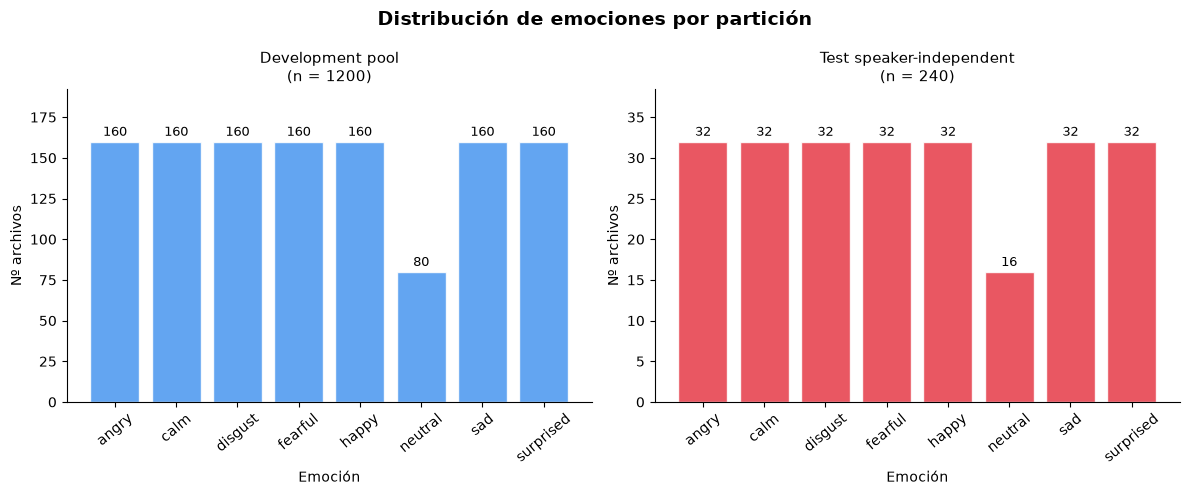

Figura guardada: reports/figures/split_class_distribution.png


In [10]:
# Distribución de emociones en cada partición
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Distribución de emociones por partición", fontsize=14, fontweight="bold")

partition_cfg = [
    (PARTITION_DEVELOPMENT, "Development pool","#4895EF"),
    (PARTITION_TEST_INDEPENDENT, "Test speaker-independent","#E63946"),
]

for ax, (part, label, color) in zip(axes, partition_cfg):
    sub = metadata_with_part[metadata_with_part["partition"] == part]
    emo = sub["emotion_original"].value_counts().sort_index()
    bars = ax.bar(emo.index, emo.values, color=color, alpha=0.85, edgecolor="white")
    ax.bar_label(bars, padding=2, fontsize=9)
    ax.set_title(f"{label}\n(n = {len(sub)})", fontsize=11)
    ax.set_xlabel("Emoción")
    ax.set_ylabel("Nº archivos")
    ax.tick_params(axis="x", rotation=40)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylim(0, max(emo.values) * 1.2)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "split_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: reports/figures/split_class_distribution.png")

---
## 7 · Construcción de folds (Cross-Validation)

Los folds se calculan **una sola vez** y se persisten en `splits.parquet`. No se reconstruyen por modelo ni por representación.

| Protocolo | Splitter | `groups` | Garantía |
|---|---|---|---|
| `speaker_independent` | `StratifiedGroupKFold` | `actor_id` | Ningún actor aparece en train y val del mismo fold |

El valor `-1` indica que el registro pertenece a test y no participa en CV.

In [11]:
from src.data.splits import build_splits_dataframe
from src.utils.io import save_parquet
import pandas as pd

splits_df = build_splits_dataframe(
    metadata = metadata_with_part,
    test_independent_actors = TEST_INDEPENDENT_ACTORS,
    n_splits = CV_FOLDS,
    seed = SEED,
    target_col = "emotion_original",
)

save_parquet(splits_df, SPLITS_PATH)

part_counts = splits_df["partition"].value_counts()
print(f"\nsplits.parquet guardado: {len(splits_df)} registros.")
for part in [PARTITION_DEVELOPMENT, PARTITION_TEST_INDEPENDENT]:
    print(f"{part:<25}: {part_counts.get(part, 0)}")

# Distribución de folds en development
dev_splits = splits_df[splits_df["partition"] == PARTITION_DEVELOPMENT]
print("\nAsignación de folds (development pool)")
print(f"{'Fold':<6}  {'speaker_independent':>20}")
for fold in range(CV_FOLDS):
    n_indep = (dev_splits["fold_speaker_independent"] == fold).sum()
    print(f"{fold:<6}  {n_indep:>20}")

2026-07-04 15:02:46 | INFO     | src.data.splits | ✓ Particiones disjuntas verificadas.
2026-07-04 15:02:46 | INFO     | src.data.splits | Particiones asignadas:
partition
development                 1200
test_speaker_independent     240

Grupos por partición:
partition
development                 600
test_speaker_independent    120
2026-07-04 15:02:46 | INFO     | src.data.splits | ✓ StratifiedGroupKFold [speaker_independent] completado con 5 folds.
2026-07-04 15:02:46 | INFO     | src.data.splits | splits.parquet construido: 1440 registros.
  development: 1200
  test_independent: 240

splits.parquet guardado: 1440 registros.
development              : 1200
test_speaker_independent : 240

Asignación de folds (development pool)
Fold     speaker_independent
0                        240
1                        240
2                        240
3                        240
4                        240


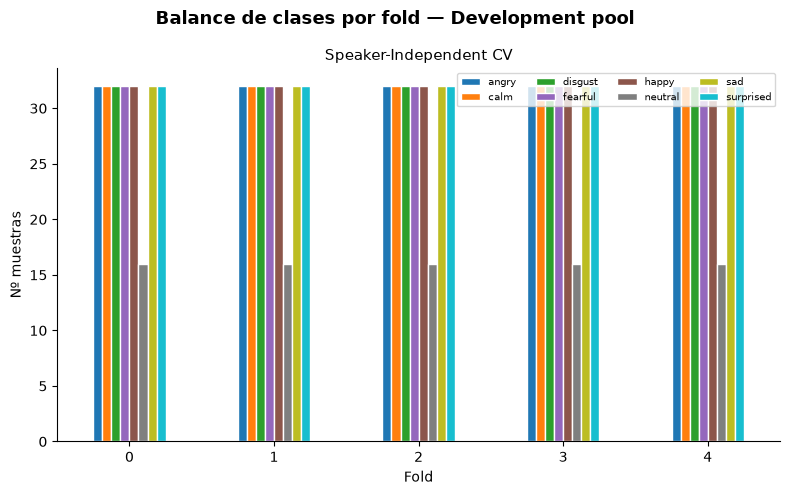

In [12]:
# Verificación visual: balance de clases por fold
merged_dev = (
    metadata_with_part
    .merge(splits_df.drop(columns=["partition"]), on="file_id")
    .query("partition == @PARTITION_DEVELOPMENT")
)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
fig.suptitle("Balance de clases por fold — Development pool", fontsize=13, fontweight="bold")

pivot = (
    merged_dev.groupby(["fold_speaker_independent", "emotion_original"])
    .size().unstack(fill_value=0)
)
pivot.plot(kind="bar", ax=ax, legend=True, colormap="tab10", edgecolor="white")
ax.set_title("Speaker-Independent CV", fontsize=11)
ax.set_xlabel("Fold")
ax.set_ylabel("Nº muestras")
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=7, ncol=4, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fold_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8 · Trimming de audio

Se eliminan silencios extremos respetando la señal original:

| Parámetro | Valor | Justificación |
|---|---|---|
| `frame_length` | 25 ms | Estándar en análisis de voz |
| `hop_length` | 10 ms | Resolución temporal suficiente |
| `threshold_db` | -35 dB | Relativo al RMS máximo; conservador para no cortar |
| `padding` | 150 ms | Preserva contexto de onset/offset emocional |

**No se aplica:** normalización de amplitud, compresión, noise reduction, ni eliminación de silencios internos ya que altereran la prosodia y propiedades acústicas.

In [13]:
from src.data.audio_cleaning import process_all_audio, merge_trim_metrics

trim_df = process_all_audio(
    metadata = metadata,
    sample_rate = SAMPLE_RATE,
    frame_length_ms = FRAME_LENGTH_MS,
    hop_length_ms = HOP_LENGTH_MS,
    threshold_db = THRESHOLD_DB,
    padding_ms = PADDING_MS,
    trim_ratio_warning = TRIM_RATIO_WARN,
    overwrite = True,
    verbose_every = 200,
)

metadata = merge_trim_metrics(metadata, trim_df)

2026-07-04 15:02:47 | INFO     | src.data.audio_cleaning | Trimming 0/1440 — 03-01-01-01-01-01-01


c:\Users\alega\OneDrive\Documentos\std\Speech_Emotion_Recognition\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-07-04 15:02:50 | WARNING  | src.data.audio_cleaning | trim_ratio=0.51 > 0.5 en 03-01-01-01-01-01-13.wav. Inspeccionar.
2026-07-04 15:02:50 | WARNING  | src.data.audio_cleaning | trim_ratio=0.50 > 0.5 en 03-01-01-01-01-02-13.wav. Inspeccionar.
2026-07-04 15:02:51 | WARNING  | src.data.audio_cleaning | trim_ratio=0.51 > 0.5 en 03-01-01-01-02-01-01.wav. Inspeccionar.
2026-07-04 15:02:51 | WARNING  | src.data.audio_cleaning | trim_ratio=0.51 > 0.5 en 03-01-01-01-02-01-04.wav. Inspeccionar.
2026-07-04 15:02:51 | WARNING  | src.data.audio_cleaning | trim_ratio=0.51 > 0.5 en 03-01-01-01-02-01-13.wav. Inspeccionar.
2026-07-04 15:02:51 | WARNING  | src.data.audio_cleaning | trim_ratio=0.51 > 0.5 en 03-01-01-01-02-02-01.wav. Inspeccionar.
2026-07-04 15:02:51 | WARNING  | src.data.audio_cleaning | trim_ratio=0.51 > 0.5 en 03-01-01-01-02-02-13.wav. Inspeccionar.
2026-07-04 15:02:52 | WARNING  | src.data.audio_cleaning | trim_ratio=0.51 > 0.5 en 03-01-02-01-01-02-17.wav. Inspeccionar.
2026-07-

In [14]:
# Estadísticas de trimming
trim_cols = ["duration_raw_s", "duration_trimmed_s", "trim_ratio"]
stats = metadata[trim_cols].describe().loc[["min", "mean", "50%", "max", "std"]]
stats.index = ["min", "mean", "median", "max", "std"]

print("ESTADÍSTICAS DE TRIMMING")
print()
print(f"{'':22} {'min':>7} {'mean':>7} {'median':>7} {'max':>7} {'std':>7}")
for col in trim_cols:
    row = stats[col]
    print(f"{col:<22} {row['min']:>7.2f} {row['mean']:>7.2f} {row['median']:>7.2f} "
          f"{row['max']:>7.2f} {row['std']:>7.2f}")

n_excessive = (metadata["trim_ratio"] > TRIM_RATIO_WARN).sum()
pct = n_excessive / len(metadata) * 100
print(f"\n Archivos con trim_ratio > {TRIM_RATIO_WARN} : {n_excessive} ({pct:.1f}% del total)")

# Emociones más afectadas
emo_trim = (
    metadata.groupby("emotion_original")["trim_ratio"]
    .median().sort_values(ascending=False).head(3)
)
print("\nEmociones más afectadas por trim alto:")
for emo, val in emo_trim.items():
    print(f"{emo:<12} mediana {val:.2f}")

print("\nEstas emociones tienen onsets más tardíos.")
print(f"Con padding={PADDING_MS}ms el contenido emocional relevante se preserva.")

ESTADÍSTICAS DE TRIMMING

                           min    mean  median     max     std
duration_raw_s            2.94    3.70    3.67    5.27    0.34
duration_trimmed_s        1.39    2.26    2.15    4.43    0.49
trim_ratio                0.00    0.39    0.42    0.54    0.11

 Archivos con trim_ratio > 0.5 : 83 (5.8% del total)

Emociones más afectadas por trim alto:
surprised    mediana 0.46
neutral      mediana 0.45
happy        mediana 0.44

Estas emociones tienen onsets más tardíos.
Con padding=150ms el contenido emocional relevante se preserva.


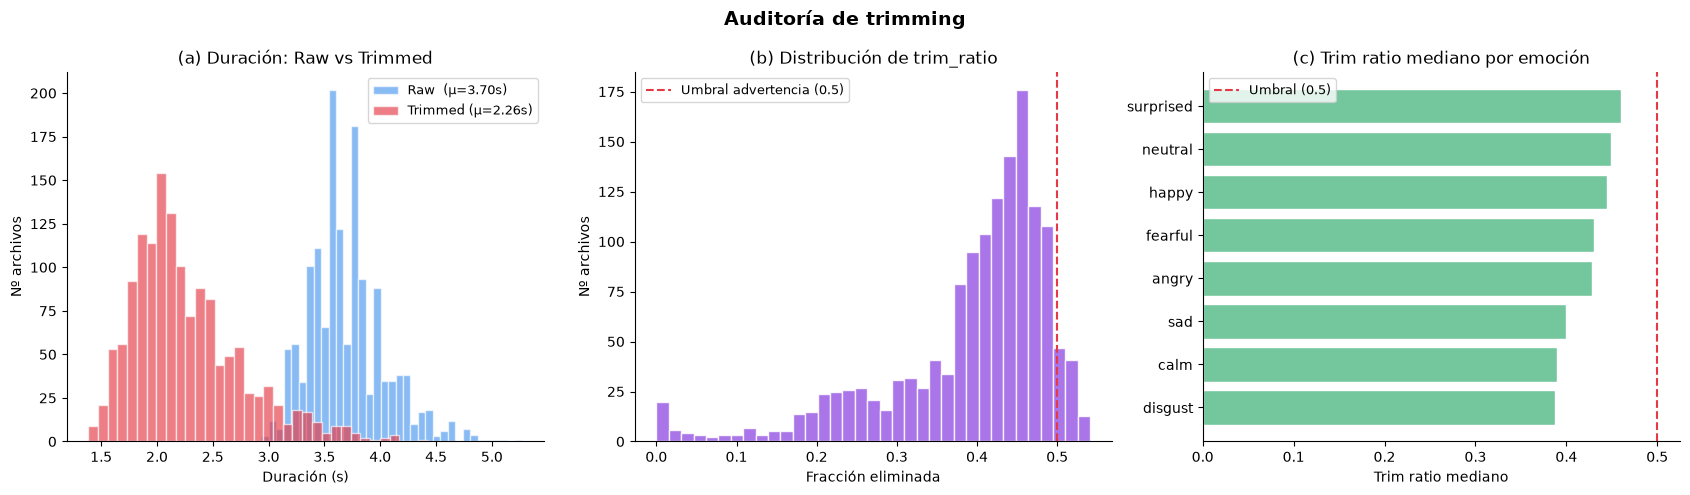

Figura guardada: reports/figures/trim_duration_comparison.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Auditoría de trimming", fontsize=14, fontweight="bold")

# (a) Raw vs Trimmed
axes[0].hist(metadata["duration_raw_s"].dropna(), bins=35, alpha=0.65,
             label=f"Raw  (μ={metadata['duration_raw_s'].mean():.2f}s)",
             color="#4895EF", edgecolor="white")
axes[0].hist(metadata["duration_trimmed_s"].dropna(), bins=35, alpha=0.65,
             label=f"Trimmed (μ={metadata['duration_trimmed_s'].mean():.2f}s)",
             color="#E63946", edgecolor="white")
axes[0].set_title("(a) Duración: Raw vs Trimmed")
axes[0].set_xlabel("Duración (s)")
axes[0].set_ylabel("Nº archivos")
axes[0].legend(fontsize=9)
axes[0].spines[["top", "right"]].set_visible(False)

# (b) Distribución de trim_ratio
axes[1].hist(metadata["trim_ratio"].dropna(), bins=35,
             color="#9B5DE5", edgecolor="white", alpha=0.85)
axes[1].axvline(TRIM_RATIO_WARN, color="#E63946", linestyle="--", linewidth=1.5,
                label=f"Umbral advertencia ({TRIM_RATIO_WARN})")
axes[1].set_title("(b) Distribución de trim_ratio")
axes[1].set_xlabel("Fracción eliminada")
axes[1].set_ylabel("Nº archivos")
axes[1].legend(fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

# (c) Trim ratio mediano por emoción
emo_trim_all = (
    metadata.groupby("emotion_original")["trim_ratio"]
    .median().sort_values(ascending=True)
)
colors_bar = ["#E63946" if v > TRIM_RATIO_WARN else "#74C69D" for v in emo_trim_all.values]
bars = axes[2].barh(emo_trim_all.index, emo_trim_all.values,
                    color=colors_bar, edgecolor="white")
axes[2].axvline(TRIM_RATIO_WARN, color="#E63946", linestyle="--", linewidth=1.5,
                label=f"Umbral ({TRIM_RATIO_WARN})")
axes[2].set_title("(c) Trim ratio mediano por emoción")
axes[2].set_xlabel("Trim ratio mediano")
axes[2].legend(fontsize=9)
axes[2].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "trim_duration_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: reports/figures/trim_duration_comparison.png")

### Lectura de la auditoría de trimming

Los números confirman la hipótesis de diseño: el trimming es agresivo pero no destructivo.

- La duración media cae de 3.70 s (raw) a 2.26 s (trimmed) — una reducción promedio del 39%, con un mínimo de 1.39 s, más que suficiente para extraer eGeMAPS o embeddings wav2vec sin perder estabilidad estadística.
- 83 de 1440 archivos (5.8%) superan el umbral de advertencia (`trim_ratio > 0.5`) — el log del proceso reportó 84 advertencias durante la ejecución streaming; la diferencia de 1 archivo es un caso límite justo en el umbral (0.50 vs. 0.50) y no afecta ninguna conclusión, pero queda anotado para no perderlo de vista.
- Las tres emociones con mayor trim ratio mediano son `surprised` (0.46), `neutral` (0.45) y `happy` (0.44) — consistente con la idea de que estas expresiones tienden a tener onsets más tardíos (el actor "carga" la emoción antes de hablar). El padding de 150 ms protege ese contenido en vez de cortarlo de raíz.

En síntesis: no hay evidencia de que el trimming esté eliminando señal emocional relevante, y los 83 casos límite quedan documentados para revisarlos puntualmente si algún modelo posterior muestra un patrón de error correlacionado con ellos.

In [16]:
from src.utils.io import save_parquet
save_parquet(metadata, METADATA_PATH)
print(f"metadata.parquet guardado: {metadata.shape[0]} filas × {metadata.shape[1]} columnas")

metadata.parquet guardado: 1440 filas × 23 columnas


---
## 9 · Auditoría de leakage

Se verifican **5 condiciones bloqueantes**:

| # | Condición |
|---|---|
| 1 | Actores de `test_independent` no aparecen en `development` |
| 2 | Cero overlap de `file_id` entre `development` y `test_independent` |
| 3 | Archivos de test tienen `FOLD_SENTINEL = -1` |
| 4 | Todos los archivos de development tienen fold asignado |
| 5 | `test_independent` contiene ambos sexos |

In [17]:
from src.validation.leakage import audit_leakage
from src.validation.sanity import validate_metadata, validate_splits, validate_trimmed_audio
from src.utils.io import load_metadata, load_splits

meta_loaded = load_metadata(METADATA_PATH)
splits_loaded = load_splits(SPLITS_PATH)

sanity_meta = validate_metadata(meta_loaded)
sanity_splits = validate_splits(splits_loaded, meta_loaded)
sanity_audio = validate_trimmed_audio(meta_loaded, sample_size=50)
leakage_rpt = audit_leakage(meta_loaded, splits_loaded)

# Checklist dinámico — refleja el estado real del reporte
print("AUDITORÍA DE LEAKAGE")
print()

# Mapear cada condición al resultado real del LeakageReport
checks = [
    ("Actores test_independent aislados", not any("Actores en test_independent" in e for e in leakage_rpt.errors)),
    ("Sin file overlap entre particiones", not any("file_id overlap" in e for e in leakage_rpt.errors)),
    ("Archivos de test con FOLD_SENTINEL", not any("fold asignado en" in e for e in leakage_rpt.errors)),
    ("Development con folds asignados", not any("SIN fold en" in e for e in leakage_rpt.errors)),
    ("Ambos sexos en test_independent", not any("ambos sexos" in w for w in leakage_rpt.warnings)),
]
for i_c, (label, ok) in enumerate(checks, 1):
    icon = "PASS" if ok else " FAIL"
    print(f"[{i_c}] {label} {icon}")

print("\nRESUMEN DE SANIDAD")
print()
for label, rpt in [
    ("Sanity metadata", sanity_meta),
    ("Sanity splits", sanity_splits),
    ("Sanity audio", sanity_audio),
    ("Leakage audit", leakage_rpt),
]:
    print(f"{label}: {rpt.status}")
    for w in rpt.warnings:
        print(f"WAR: {w}")
    for e in rpt.errors:
        print(f"ERR: {e}")

all_pass = all([
    sanity_meta.passed, sanity_splits.passed,
    sanity_audio.passed, leakage_rpt.passed,
])
n_warn = sum(bool(r.warnings) for r in [sanity_meta, sanity_splits, sanity_audio, leakage_rpt])
sprint_status = (
    "PASS" if all_pass and n_warn == 0
    else f"PASS WITH WARNINGS ({n_warn})" if all_pass
    else "FAIL"
)


2026-07-04 15:03:10 | INFO     | src.validation.sanity | 
SanityReport [metadata] — PASS WITH WARNINGS
  [WARN]  trim_ratio > 0.50 en 83 audios. Inspeccionar: ['03-01-01-01-01-01-13', '03-01-01-01-01-02-13', '03-01-01-01-02-01-01']
2026-07-04 15:03:10 | INFO     | src.validation.sanity | 
SanityReport [splits] — PASS
  Todas las verificaciones pasaron.
2026-07-04 15:03:10 | INFO     | src.validation.sanity | Audio validation: 50/50 archivos verificados correctamente.
2026-07-04 15:03:10 | INFO     | src.validation.sanity | 
SanityReport [audio] — PASS
  Todas las verificaciones pasaron.
2026-07-04 15:03:10 | INFO     | src.validation.leakage | ✓ [1] Actores test_independent completamente aislados de development.
2026-07-04 15:03:10 | INFO     | src.validation.leakage | ✓ [2] Sin file overlap: development ∩ test_independent = ∅
2026-07-04 15:03:10 | INFO     | src.validation.leakage | ✓ [3] Archivos de test tienen FOLD_SENTINEL en 'fold_speaker_independent'.
2026-07-04 15:03:10 | INFO  

In [18]:
from src.data.splits import build_splits_dataframe

splits_v2 = build_splits_dataframe(
    metadata = metadata_with_part,
    test_independent_actors = TEST_INDEPENDENT_ACTORS,
    n_splits = CV_FOLDS,
    seed = SEED,
    target_col = "emotion_original",
)

comp = splits_df.merge(
    splits_v2.rename(columns={
        "partition": "partition_v2",
        "fold_speaker_independent":"fold_indep_v2",
    }), on = "file_id",
)
assert (comp["partition"] == comp["partition_v2"]).all()
assert (comp["fold_speaker_independent"] == comp["fold_indep_v2"]).all()
print("Reproducibilidad confirmada, particiones y folds idénticos en 2 ejecuciones independientes: OK")

2026-07-04 15:03:10 | INFO     | src.data.splits | ✓ Particiones disjuntas verificadas.
2026-07-04 15:03:10 | INFO     | src.data.splits | Particiones asignadas:
partition
development                 1200
test_speaker_independent     240

Grupos por partición:
partition
development                 600
test_speaker_independent    120
2026-07-04 15:03:10 | INFO     | src.data.splits | ✓ StratifiedGroupKFold [speaker_independent] completado con 5 folds.
2026-07-04 15:03:10 | INFO     | src.data.splits | splits.parquet construido: 1440 registros.
  development: 1200
  test_independent: 240
Reproducibilidad confirmada, particiones y folds idénticos en 2 ejecuciones independientes: OK


---
## 10 · Conclusiones del notebook

### A considerar

- **Corpus:** 1440 archivos, 24 actores (12M/12F), 8 emociones balanceadas a 192 muestras salvo `neutral` (96, por diseño de RAVDESS — no graba intensidad "strong" para neutral).
- **Cuadrantes de Russell:** Q1=384, Q2=576, Q3=192, Q4=288 — el desbalance 3:1 entre Q2 y Q3 es la razón principal para usar `class_weight='balanced'` en los modelos de Sprint 3.
- **Partición:** 1200 development (83.3%) / 240 test speaker-independent (16.7%), actores de test `[2, 6, 21, 23]` con balance de sexo 2F+2M.
- **CV:** `StratifiedGroupKFold` con `actor_id` como grupo, 5 folds perfectamente balanceados en tamaño (240 muestras cada uno) dentro de development.
- **Trimming:** −35 dB de umbral, 150 ms de padding → duración media 3.70 s → 2.26 s (−39%), 83/1440 archivos (5.8%) por encima del umbral de advertencia de `trim_ratio`.
- **Auditoría de leakage:** las 5 condiciones bloqueantes pasaron sin excepción, y la reconstrucción de `splits.parquet` en una segunda corrida independiente produjo partición y folds idénticos — la pipeline es determinística de punta a punta.

### Decisiones tomadas y su justificación

**1. Balance de sexo en test:** incluir dos actores femeninos y dos masculinos evita que la evaluación speaker-independent quede concentrada en un único sexo y reduce un posible sesgo de composición. Este balance no demuestra por sí solo que el modelo sea independiente de características vocales asociadas al sexo.


**2. Trimming conservador (−35 dB, 150 ms padding):** la inspección de emociones de alta arousal y onset tardío (`surprised`, `neutral`, `happy` — trim ratio mediano 0.44–0.46) confirma que un umbral más agresivo habría cortado contenido emocional relevante antes de que empezara el habla.

**3. Los 83 archivos con trim_ratio > 0.50** corresponden mayoritariamente a emociones con silencios iniciales pronunciados. El contenido útil restante sigue siendo ≥ 1.39 s — suficiente margen para extracción de features tanto expertas (eGeMAPS) como basadas en SSL (wav2vec). Quedan identificados por `file_id` en el log de esta corrida por si algún modelo posterior necesita revisarlos puntualmente.